In [2]:
import torch
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from flowpde.datasets.exponax import PoissonGenerator, PoissonConfig
from flowpde.models.unet import UNet
from flowpde.datasets.normalization import FieldNormalizer
from flowpde.flows import NeuralODEFlow
from flowpde.objectives import FlowMatchingObjective
from flowpde.trainers.evaluation import FlowEvaluator
from flowpde.trainers import Trainer

In [3]:
cfg = PoissonConfig()
generator = PoissonGenerator(cfg)
train_data = generator.generate(num_samples = 1000, seed=0, problem='forward')
val_data   = generator.generate(num_samples = 50, seed=1, problem='forward')

Generated Poisson 2D dataset: 1000 samples, 64x64 grid
Generated Poisson 2D dataset: 50 samples, 64x64 grid


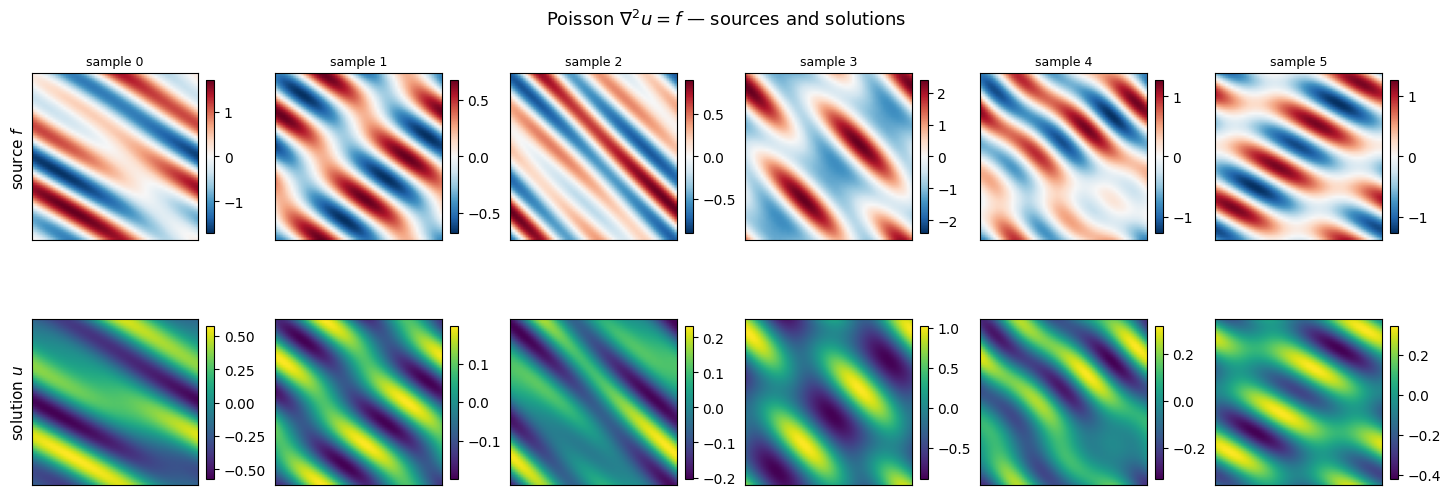

In [4]:
n=6
fig, axes = plt.subplots(2, n, figsize=(2.4 * n, 5.2), constrained_layout=True)

for j in range(n):
    f = train_data.data['source'][j].squeeze().cpu().numpy()      # (H, W)
    u = train_data.data['solution'][j].squeeze().cpu().numpy()

    for row, (field, name, cmap) in enumerate(
        [(f, 'source $f$', 'RdBu_r'), (u, 'solution $u$', 'viridis')]
    ):
        ax = axes[row, j]
        vmax = abs(field).max()
        im = ax.imshow(
            field, cmap=cmap, origin='lower',
            **({'vmin': -vmax, 'vmax': vmax} if row == 0 else {}),
        )
        ax.set_xticks([]); ax.set_yticks([])
        if j == 0:
            ax.set_ylabel(name, fontsize=11)
        if row == 0:
            ax.set_title(f'sample {j}', fontsize=9)
        fig.colorbar(im, ax=ax, fraction=0.046, shrink=0.9)

fig.suptitle(r'Poisson $\nabla^2 u = f$ — sources and solutions', fontsize=13)
plt.show()

In [5]:
normalizer = FieldNormalizer.from_dataset(train_data)
train_data.set_normalizer(normalizer)
val_data.set_normalizer(normalizer)

In [6]:
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64)
sample = train_data[0]
cond_ch = sample['input'].shape[0]      # +1 if obs masking is on
targ_ch = sample['target'].shape[0]
cond_ch, targ_ch

(1, 1)

In [7]:
device = torch.device('mps' if torch.mps.is_available() else 'cpu')
print(f"Using device: {device}")
model = UNet(spatial_dim = 2,
            spatial_size = 64,
            base_channels = 64,
            solution_channels = targ_ch,
            condition_channels = cond_ch,
            use_attention = False).to(device)

Using device: mps


In [8]:
flow = NeuralODEFlow(model, 
                target_key = 'target', 
                condition_key = 'input')
flow = flow.to(device).float()

In [9]:
objective = FlowMatchingObjective(flow,
                                path = 'linear',
                                time_sampler = 'uniform')

In [10]:
optimizer = torch.optim.Adam(objective.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200)

In [11]:
evaluator = FlowEvaluator(objective, 
                          val_loader,
                          target_key='target',
                          condition_key='input',
                          n_steps = 50,
                          solver='euler',
                          normalizer=normalizer,
                          target_fields=val_data.target_fields,
                          metrics=['rel_l2'],
                          max_batches=4,)

In [12]:
trainer = Trainer(objective,
                  optimizer,
                  scheduler,
                  device)

In [13]:
trainer.train(train_loader,
             epochs = 10,
             print_stats_interval = 10,
             save_dir='runs/poisson2d_fm',
             save_interval=25)

Epoch: 0001/10 | Train_Loss: 1.722112 | LR: 1.00e-03 | Time: 21.985577
Saved loss curve to runs/poisson2d_fm/training_curve.png

Best train loss: 0.094033
Best model saved to: runs/poisson2d_fm/best_model.pt


In [14]:
model.to('cpu')

UNet(
  spatial_dim=2, spatial_size=64, depth=4, base_channels=64, solution_channels=1, condition_channels=1
  (conditioner): ConcatConditioner(dim=1)
  (time_embed): TimeMLPEmbedding(
    (fourier): FourierTimeEmbedding(
      (proj): Identity()
    )
    (mlp): Sequential(
      (0): Linear(in_features=256, out_features=1024, bias=True)
      (1): SiLU()
      (2): Linear(in_features=1024, out_features=256, bias=True)
    )
  )
  (encoder_blocks): ModuleList(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(2, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): GroupNorm(32, 64, eps=1e-05, affine=True, bias=True)
        (2): SiLU()
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): GroupNorm(32, 64, eps=1e-05, affine=True, bias=True)
        (5): SiLU()
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): Grou

In [15]:
flow.to('cpu')

NeuralODEFlow(
  base_distribution=gaussian
  (model): UNet(
    spatial_dim=2, spatial_size=64, depth=4, base_channels=64, solution_channels=1, condition_channels=1
    (conditioner): ConcatConditioner(dim=1)
    (time_embed): TimeMLPEmbedding(
      (fourier): FourierTimeEmbedding(
        (proj): Identity()
      )
      (mlp): Sequential(
        (0): Linear(in_features=256, out_features=1024, bias=True)
        (1): SiLU()
        (2): Linear(in_features=1024, out_features=256, bias=True)
      )
    )
    (encoder_blocks): ModuleList(
      (0): ConvBlock(
        (block): Sequential(
          (0): Conv2d(2, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): GroupNorm(32, 64, eps=1e-05, affine=True, bias=True)
          (2): SiLU()
          (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (4): GroupNorm(32, 64, eps=1e-05, affine=True, bias=True)
          (5): SiLU()
        )
      )
      (1): ConvBlock(
        (block): Sequ

In [17]:
batch = next(iter(val_loader))
cond = batch["input"].to(device='cpu')

with torch.no_grad():
    u_hat = flow.sample(
        condition=cond,
        n_steps=50,
        target_shape=batch["target"].shape[1:],
    )

target = batch["target"].to(device='cpu')
u_hat = normalizer.denormalize(
    u_hat.view_as(target),
    val_ds.target_fields,
)

NameError: name 'val_ds' is not defined